# --- Імпорти

In [18]:
import json, time
import joblib
import numpy as np
import pandas as pd
import optuna
import ast
from pathlib import Path

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import ParameterGrid
from sklearn.utils.class_weight import compute_class_weight

from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool

from src.models.ML_models_tripl import *
from src.utils.data_utils import *


import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb


In [5]:
RANDOM_STATE = 42
ART_DIR = Path("artifacts")
ART_DIR.mkdir(exist_ok=True, parents=True)

def compute_tp_f1_from_preds(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    m = triple_barrier_metrics(cm)
    return m["tp_f1"]

def fit_and_eval(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return compute_tp_f1_from_preds(y_val, preds), model

def save_best(model_name, ku, kd, hold, best_params, best_model):
    tag = f"ku{ku}_kd{kd}_hold{hold}"
    # гіперпараметри
    with open(ART_DIR / f"{model_name}_{tag}_best_params.json", "w") as f:
        json.dump(best_params, f, indent=2)
    # модель (де можливо)
    if model_name == "RandomForest":
        import joblib
        joblib.dump(best_model, ART_DIR / f"{model_name}_{tag}.pkl")
    elif model_name == "LightGBM":
        # збережемо booster у txt
        best_model.booster_.save_model(str(ART_DIR / f"{model_name}_{tag}.txt"))
    elif model_name == "XGBoost":
        best_model.save_model(str(ART_DIR / f"{model_name}_{tag}.json"))
    elif model_name == "CatBoost":
        best_model.save_model(str(ART_DIR / f"{model_name}_{tag}.cbm"))

In [6]:
from pathlib import Path

BASE = Path("artifacts")
RF_DIR = BASE / "rf"
RF_DIR.mkdir(parents=True, exist_ok=True)
LGBM_DIR = BASE / "lgbm"
LGBM_DIR.mkdir(parents=True, exist_ok=True)
XGB_DIR = BASE / "xgb"
XGB_DIR.mkdir(parents=True, exist_ok=True)
CAT_DIR = BASE / "cat"
CAT_DIR.mkdir(parents=True, exist_ok=True)

print("Папки створені ✅")


Папки створені ✅


In [7]:
df = pd.read_parquet("data/processed/BTC_USDT_15m_futures.parquet")

print("✅ Файл прочитано. Розмір:", df.shape)
df.head()


✅ Файл прочитано. Розмір: (205109, 70)


,open,high,low,close,volume,funding_rate,ema_20,ema_50,ema_200,macd,...,hour_cos,dayofweek_sin,dayofweek_cos,session_Asia,session_Frankfurt,session_London,session_NewYork,session_OffHours,pda_Discount,pda_Premium
0,6909.83,6909.83,6872.78,6884.74,7.886164,-0.000017,-2.814693,-5.059633,-11.835218,-1.076070,...,0.965926,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,6884.72,6900.84,6863.44,6900.52,7.778294,-0.000017,-1.805547,-3.971036,-10.479156,-1.060945,...,0.866025,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,6900.46,6943.00,6900.46,6938.92,7.901142,-0.000017,-0.119535,-2.089074,-8.229299,-0.890728,...,0.866025,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,6938.91,6960.00,6937.61,6950.01,7.711550,-0.000017,0.304085,-1.580837,-7.744898,-0.762934,...,0.866025,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,6950.01,6959.00,6941.27,6952.58,6.956475,-0.000017,0.378111,-1.445149,-7.712092,-0.654092,...,0.866025,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0


# ---RandomForest

In [ ]:
def tune_random_forest_for_ku_kd(df, KU, KD, HOLD=48):

    print(f"\n============== RF: KU={KU}, KD={KD}, HOLD={HOLD} ==============\n")

    # 1) Лейблінг
    df_labeled = triple_barrier_label(
        df,
        close="close",
        high="high",
        low="low",
        volatility="atr_14",
        ku=KU,
        kd=KD,
        hold=HOLD
    )

    # 2) Спліт + скейлінг
    train_df, val_df, test_df, scaler = split_scale(
        df_labeled,
        target_cols="y",
        test_size=0.15,
        val_size=0.15,
        scale=True
    )

    X_train = train_df.drop(columns=["y"])
    y_train = train_df["y"]
    X_val = val_df.drop(columns=["y"])
    y_val = val_df["y"]

    # 3) Ваги класів
    classes = np.array([0, 1, 2])
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weights = dict(zip(classes, weights))

    # 4) Тюнінг RF
    best_f1 = -1
    best_params = None
    best_model = None

    for n in [200, 400, 600]:
        for depth in [8, 12]:
            for leaf in [2, 3, 5]:
                model = RandomForestClassifier(
                    n_estimators=n,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    max_features="sqrt",
                    class_weight=class_weights,
                    n_jobs=-1,
                    random_state=42
                )

                model.fit(X_train, y_train)
                preds = model.predict(X_val)
                f1 = compute_tp_f1_from_preds(y_val, preds)

                print(f"(KU={KU}, KD={KD}) n={n}, depth={depth}, leaf={leaf} → tp_f1 = {f1:.4f}")

                if f1 > best_f1:
                    best_f1 = f1
                    best_params = {
                        "n_estimators": n,
                        "max_depth": depth,
                        "min_samples_leaf": leaf,
                        "max_features": "sqrt"
                    }
                    best_model = model

    print(f"\n✅ Найкращий tp_f1 для KU={KU}, KD={KD}: {best_f1:.4f}")
    print("🏅 Параметри:", best_params)

    # 5) Збереження
    SAVE_DIR = Path("artifacts") / "rf"
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    tag = f"ku{KU}_kd{KD}_hold{HOLD}"

    joblib.dump(best_model, SAVE_DIR / f"best_rf_{tag}.pkl")

    with open(SAVE_DIR / f"best_rf_params_{tag}.json", "w") as f:
        json.dump({
            "ku": KU,
            "kd": KD,
            "hold": HOLD,
            "best_tp_f1_val": float(best_f1),
            "best_params": best_params
        }, f, indent=2)

    print(f"RandomForest модель та параметри збережено у: {SAVE_DIR}")

    return (KU, KD, best_f1, best_params)



In [18]:
results = []

for KU, KD in [(2,1), (3,1), (4,1)]:
    res = tune_random_forest_for_ku_kd(df, KU, KD, HOLD=48)
    results.append(res)

print("\n=== RandomForest загальні результати ===\n")
for r in results:
    print(r)



============== RF: KU=2, KD=1, HOLD=48 ==============

[INFO] Using StandardScaler, scaling = True
[INFO] Total features: 70 | Scaled: 46 | Excluded: ['open', 'high', 'low', 'close', 'atr_14']
[OK] Standard scaling applied to 46 columns.
[OK] Split complete → Train: 143542, Val: 30759, Test: 30760
(KU=2, KD=1) n=200, depth=8, leaf=2 → tp_f1 = 0.5987
(KU=2, KD=1) n=200, depth=8, leaf=3 → tp_f1 = 0.6021
(KU=2, KD=1) n=200, depth=8, leaf=5 → tp_f1 = 0.6060
(KU=2, KD=1) n=200, depth=12, leaf=2 → tp_f1 = 0.5950
(KU=2, KD=1) n=200, depth=12, leaf=3 → tp_f1 = 0.5952
(KU=2, KD=1) n=200, depth=12, leaf=5 → tp_f1 = 0.6004
(KU=2, KD=1) n=400, depth=8, leaf=2 → tp_f1 = 0.6026
(KU=2, KD=1) n=400, depth=8, leaf=3 → tp_f1 = 0.6051
(KU=2, KD=1) n=400, depth=8, leaf=5 → tp_f1 = 0.6082
(KU=2, KD=1) n=400, depth=12, leaf=2 → tp_f1 = 0.5944
(KU=2, KD=1) n=400, depth=12, leaf=3 → tp_f1 = 0.5973
(KU=2, KD=1) n=400, depth=12, leaf=5 → tp_f1 = 0.5992
(KU=2, KD=1) n=600, depth=8, leaf=2 → tp_f1 = 0.6036
(KU=2

# ---lightgbm

In [27]:
def tune_lightgbm_for_ku_kd(df, KU, KD, HOLD=48):

    print(f"\n============== LightGBM: KU={KU}, KD={KD}, HOLD={HOLD} ==============\n")

    # 1) Лейблінг
    df_labeled = triple_barrier_label(
        df,
        close="close",
        high="high",
        low="low",
        volatility="atr_14",
        ku=KU,
        kd=KD,
        hold=HOLD
    )

    # 2) Спліт + cкейлінг
    train_df, val_df, test_df, scaler = split_scale(
        df_labeled,
        target_cols="y",
        test_size=0.15,
        val_size=0.15,
        scale=True
    )

    X_train = train_df.drop(columns=["y"])
    y_train = train_df["y"]
    X_val = val_df.drop(columns=["y"])
    y_val = val_df["y"]

    # 3) Ваги класів (узгоджено з DL)
    classes = np.array([0, 1, 2])
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weights = dict(zip(classes, weights))

    # 4) Тюнінг LightGBM
    best_f1 = -1
    best_params = None
    best_model = None

    for leaves in [31, 63, 127]:
        for depth in [6, 8, 12]:
            for n in [300, 600, 900]:

                model = LGBMClassifier(
                    objective="multiclass",
                    num_class=3,
                    learning_rate=0.05,
                    n_estimators=n,
                    num_leaves=leaves,
                    max_depth=depth,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    class_weight=class_weights,
                    random_state=42
                )

                model.fit(X_train, y_train)
                preds = model.predict(X_val)
                f1 = compute_tp_f1_from_preds(y_val, preds)

                print(f"(KU={KU},KD={KD}) n={n}, leaves={leaves}, depth={depth} → tp_f1 = {f1:.4f}")

                if f1 > best_f1:
                    best_f1 = f1
                    best_params = {
                        "n_estimators": n,
                        "num_leaves": leaves,
                        "max_depth": depth,
                        "learning_rate": 0.05,
                        "subsample": 0.8,
                        "colsample_bytree": 0.8
                    }
                    best_model = model

    print(f"\n✅ Найкращий tp_f1 для KU={KU}, KD={KD}: {best_f1:.4f}")
    print("🏅 Параметри:", best_params)

    # 5) Збереження
    SAVE_DIR = Path("artifacts") / "lgbm"
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    tag = f"ku{KU}_kd{KD}_hold{HOLD}"

    joblib.dump(best_model, SAVE_DIR / f"best_lgbm_{tag}.pkl")
    with open(SAVE_DIR / f"best_lgbm_params_{tag}.json", "w") as f:
        json.dump({
            "ku": KU,
            "kd": KD,
            "hold": HOLD,
            "best_tp_f1_val": float(best_f1),
            "best_params": best_params
        }, f, indent=2)

    print(f"lightgbm модель та параметри збережено у: artifacts/lgbm")
    return (KU, KD, best_f1, best_params)


In [28]:
results_lgbm = []

for KU, KD in [(2,1), (3,1), (4,1)]:
    res = tune_lightgbm_for_ku_kd(df, KU, KD, HOLD=48)
    results_lgbm.append(res)

print("\n=== LightGBM загальні результати ===\n")
for r in results_lgbm:
    print(r)



============== LightGBM: KU=2, KD=1, HOLD=48 ==============

[INFO] Using StandardScaler, scaling = True
[INFO] Total features: 70 | Scaled: 46 | Excluded: ['open', 'high', 'low', 'close', 'atr_14']
[OK] Standard scaling applied to 46 columns.
[OK] Split complete → Train: 143542, Val: 30759, Test: 30760
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035732 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11637
[LightGBM] [Info] Number of data points in the train set: 143542, number of used features: 70
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

# ---XGBoost

In [32]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from pathlib import Path
import json
import joblib
import numpy as np

def tune_xgb_for_ku_kd(df, KU, KD, HOLD=48):

    print(f"\n============== XGBoost: KU={KU}, KD={KD}, HOLD={HOLD} ==============\n")

    # 1) Лейблінг
    df_labeled = triple_barrier_label(
        df,
        close="close",
        high="high",
        low="low",
        volatility="atr_14",
        ku=KU,
        kd=KD,
        hold=HOLD
    )

    # 2) Спліт + скейлінг
    train_df, val_df, test_df, scaler = split_scale(
        df_labeled,
        target_cols="y",
        test_size=0.15,
        val_size=0.15,
        scale=True
    )

    X_train = train_df.drop(columns=["y"])
    y_train = train_df["y"]
    X_val = val_df.drop(columns=["y"])
    y_val = val_df["y"]

    # 3) Ваги класів (узгоджено з DL)
    classes = np.array([0, 1, 2])
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weights = dict(zip(classes, weights))

    # ВАЖЛИВО: створюємо weights для кожного запису
    sample_weights = y_train.map(class_weights).values

    # 4) Тюнінг XGBoost
    best_f1 = -1
    best_params = None
    best_model = None

    for depth in [6, 8]:
        for lr in [0.05, 0.1]:
            for estim in [300, 600]:

                model = XGBClassifier(
                    objective="multi:softprob",   # дає predict_proba → ідеально для threshold tuning
                    num_class=3,
                    max_depth=depth,
                    learning_rate=lr,
                    n_estimators=estim,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=42,
                    tree_method="hist",
                    eval_metric="mlogloss"
                )

                model.fit(X_train, y_train, sample_weight=sample_weights)
                preds = model.predict(X_val)
                f1 = compute_tp_f1_from_preds(y_val, preds)

                print(f"(KU={KU},KD={KD}) depth={depth}, lr={lr}, estim={estim} → tp_f1 = {f1:.4f}")

                if f1 > best_f1:
                    best_f1 = f1
                    best_params = {
                        "max_depth": depth,
                        "learning_rate": lr,
                        "n_estimators": estim,
                        "subsample": 0.8,
                        "colsample_bytree": 0.8
                    }
                    best_model = model

    print(f"\nНайкращий tp_f1 для KU={KU}, KD={KD}: {best_f1:.4f}")
    print("🏅 Параметри:", best_params)

    # 5) Збереження
    SAVE_DIR = Path("artifacts") / "xgb"
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    tag = f"ku{KU}_kd{KD}_hold{HOLD}"

    joblib.dump(best_model, SAVE_DIR / f"best_xgb_{tag}.pkl")

    with open(SAVE_DIR / f"best_xgb_params_{tag}.json", "w") as f:
        json.dump({
            "ku": KU,
            "kd": KD,
            "hold": HOLD,
            "best_tp_f1_val": float(best_f1),
            "best_params": best_params
        }, f, indent=2)

    print(f"XGBoost модель та параметри збережено у: artifacts/xgb")
    return (KU, KD, best_f1, best_params)


In [33]:
results_xgb = []

for KU, KD in [(2,1), (3,1), (4,1)]:
    res = tune_xgb_for_ku_kd(df, KU, KD, HOLD=48)
    results_xgb.append(res)

results_xgb



============== XGBoost: KU=2, KD=1, HOLD=48 ==============

[INFO] Using StandardScaler, scaling = True
[INFO] Total features: 70 | Scaled: 46 | Excluded: ['open', 'high', 'low', 'close', 'atr_14']
[OK] Standard scaling applied to 46 columns.
[OK] Split complete → Train: 143542, Val: 30759, Test: 30760
(KU=2,KD=1) depth=6, lr=0.05, estim=300 → tp_f1 = 0.6463
(KU=2,KD=1) depth=6, lr=0.05, estim=600 → tp_f1 = 0.6316
(KU=2,KD=1) depth=6, lr=0.1, estim=300 → tp_f1 = 0.6281
(KU=2,KD=1) depth=6, lr=0.1, estim=600 → tp_f1 = 0.5973
(KU=2,KD=1) depth=8, lr=0.05, estim=300 → tp_f1 = 0.6333
(KU=2,KD=1) depth=8, lr=0.05, estim=600 → tp_f1 = 0.6045
(KU=2,KD=1) depth=8, lr=0.1, estim=300 → tp_f1 = 0.6097
(KU=2,KD=1) depth=8, lr=0.1, estim=600 → tp_f1 = 0.5851

Найкращий tp_f1 для KU=2, KD=1: 0.6463
🏅 Параметри: {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.8, 'colsample_bytree': 0.8}
XGBoost модель та параметри збережено у: artifacts/xgb

============== XGBoost: KU=3, 

[(2,
  1,
  0.6463432507694563,
  {'max_depth': 6,
   'learning_rate': 0.05,
   'n_estimators': 300,
   'subsample': 0.8,
   'colsample_bytree': 0.8}),
 (3,
  1,
  0.5829876842575458,
  {'max_depth': 6,
   'learning_rate': 0.05,
   'n_estimators': 300,
   'subsample': 0.8,
   'colsample_bytree': 0.8}),
 (4,
  1,
  0.5333548439138502,
  {'max_depth': 6,
   'learning_rate': 0.05,
   'n_estimators': 300,
   'subsample': 0.8,
   'colsample_bytree': 0.8})]

# ---CatBoost

In [ ]:
# === triple-barrier метрика ===
from src.models.ML_models_tripl import triple_barrier_metrics

def compute_tp_f1_from_preds(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    m = triple_barrier_metrics(cm)
    return m["tp_f1"]

# === Оптимізація CatBoost через Optuna ===
def tune_catboost_for_ku_kd(df, KU, KD, HOLD=48, n_trials=25, artifacts_dir="artifacts"):
    print(f"\n============== CatBoost Optuna: KU={KU}, KD={KD}, HOLD={HOLD} ==============\n")

    # --- 1) triple barrier labeling ---
    df_labeled = triple_barrier_label(
        df,
        close="close", high="high", low="low",
        volatility="atr_14", ku=KU, kd=KD, hold=HOLD
    )

    # --- 2) Split + scaling ---
    train_df, val_df, test_df, scaler = split_scale(
        df_labeled, target_cols="y", test_size=0.15, val_size=0.15, scale=True
    )

    X_train = train_df.drop(columns=["y"])
    y_train = train_df["y"]
    X_val = val_df.drop(columns=["y"])
    y_val = val_df["y"]

    # --- 3) Compute class weights (як у DL-моделях) ---
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weights = dict(zip(classes, weights))

    # --- 4) Оптимізація через Optuna ---
    def objective(trial):
        params = {
            "loss_function": "MultiClass",
            "depth": trial.suggest_int("depth", 5, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 2, 15),
            "iterations": trial.suggest_int("iterations", 300, 600),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.1, 3.0),
            "random_seed": 42,
            "class_weights": list(class_weights.values()),
            "verbose": False
        }

        model = CatBoostClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=False
        )

        preds = model.predict(X_val)
        f1 = compute_tp_f1_from_preds(y_val, preds)
        return f1

    print("🔍 Запуск Optuna...")
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    # --- 5) Найкраща модель ---
    best_params = study.best_params
    print(f"🏆 Найкращі параметри для KU={KU}, KD={KD}:")
    print(json.dumps(best_params, indent=2))

    # Навчимо фінальну модель
    best_model = CatBoostClassifier(
        loss_function="MultiClass",
        **best_params,
        random_seed=42,
        class_weights=list(class_weights.values()),
        verbose=False
    )
    best_model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))

    # --- 6) Збереження результатів ---
    model_path = f"{artifacts_dir}/cat/catboost_optuna_ku{KU}_kd{KD}_hold{HOLD}.pkl"
    params_path = f"{artifacts_dir}/cat/catboost_optuna_params_ku{KU}_kd{KD}_hold{HOLD}.json"

    joblib.dump(best_model, model_path)
    with open(params_path, "w") as f:
        json.dump({
            "ku": KU,
            "kd": KD,
            "hold": HOLD,
            "best_tp_f1_val": float(study.best_value),
            "best_params": best_params
        }, f, indent=2)

    print(f"✅ CatBoost Optuna збережено у {artifacts_dir}")
    return KU, KD, study.best_value, best_params

In [40]:
# === Запуск для трьох комбінацій KU/KD ===
results = []
for KU, KD in [(2, 1), (3, 1), (4, 1)]:
    res = tune_catboost_for_ku_kd(df, KU, KD, HOLD=48, n_trials=25, artifacts_dir="artifacts")
    results.append(res)

print("\n=== CatBoost Optuna результати ===\n")
for r in results:
    print(r)


============== CatBoost Optuna: KU=2, KD=1, HOLD=48 ==============

[INFO] Using StandardScaler, scaling = True
[INFO] Total features: 70 | Scaled: 46 | Excluded: ['open', 'high', 'low', 'close', 'atr_14']
[OK] Standard scaling applied to 46 columns.


[I 2025-11-12 02:15:52,652] A new study created in memory with name: no-name-ad740a52-5dc9-45d5-ae8c-1e1ee32a64a2


[OK] Split complete → Train: 143542, Val: 30759, Test: 30760
🔍 Запуск Optuna...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-11-12 02:16:15,816] Trial 0 finished with value: 0.6167037449017426 and parameters: {'depth': 5, 'learning_rate': 0.053009258717549676, 'l2_leaf_reg': 11.310074679995031, 'iterations': 453, 'bagging_temperature': 0.5376857881251333}. Best is trial 0 with value: 0.6167037449017426.
[I 2025-11-12 02:16:36,198] Trial 1 finished with value: 0.6083361056983985 and parameters: {'depth': 5, 'learning_rate': 0.07486538001208079, 'l2_leaf_reg': 2.4324743277807617, 'iterations': 347, 'bagging_temperature': 1.2467737349611345}. Best is trial 0 with value: 0.6167037449017426.
[I 2025-11-12 02:16:53,196] Trial 2 finished with value: 0.6027179750618783 and parameters: {'depth': 7, 'learning_rate': 0.09277659179515477, 'l2_leaf_reg': 6.072044716577338, 'iterations': 503, 'bagging_temperature': 1.8769847047239225}. Best is trial 0 with value: 0.6167037449017426.
[I 2025-11-12 02:17:08,163] Trial 3 finished with value: 0.6062641937925815 and parameters: {'depth': 5, 'learning_rate': 0.097985814

...

[I 2025-11-12 02:39:48,095] Trial 0 finished with value: 0.5599080987937967 and parameters: {'depth': 9, 'learning_rate': 0.06998963753805798, 'l2_leaf_reg': 6.658087592140594, 'iterations': 468, 'bagging_temperature': 0.7742826030253495}. Best is trial 0 with value: 0.5599080987937967.
[I 2025-11-12 02:41:25,562] Trial 1 finished with value: 0.5581046806548305 and parameters: {'depth': 10, 'learning_rate': 0.07127967156278943, 'l2_leaf_reg': 10.294914725075326, 'iterations': 332, 'bagging_temperature': 1.1990571590507222}. Best is trial 0 with value: 0.5599080987937967.
[I 2025-11-12 02:41:49,116] Trial 2 finished with value: 0.5610468512676714 and parameters: {'depth': 6, 'learning_rate': 0.06645087438952797, 'l2_leaf_reg': 6.425270825857973, 'iterations': 543, 'bagging_temperature': 0.6364845414826616}. Best is trial 2 with value: 0.5610468512676714.
[I 2025-11-12 02:42:13,966] Trial 3 finished with value: 0.5520550320827794 and parameters: {'depth': 7, 'learning_rate': 0.0554939824

[I 2025-11-12 03:09:36,803] A new study created in memory with name: no-name-79e4e7f4-4183-4f26-b526-10f821b6149f


[OK] Split complete → Train: 143542, Val: 30759, Test: 30760
🔍 Запуск Optuna...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-11-12 03:10:20,357] Trial 0 finished with value: 0.5103398409255242 and parameters: {'depth': 6, 'learning_rate': 0.06617627256430594, 'l2_leaf_reg': 14.89201166254718, 'iterations': 476, 'bagging_temperature': 2.894889194434208}. Best is trial 0 with value: 0.5103398409255242.
[I 2025-11-12 03:10:47,156] Trial 1 finished with value: 0.5123859191655802 and parameters: {'depth': 6, 'learning_rate': 0.05681576704554907, 'l2_leaf_reg': 3.9348334766303616, 'iterations': 521, 'bagging_temperature': 1.28610182690685}. Best is trial 1 with value: 0.5123859191655802.
[I 2025-11-12 03:11:36,792] Trial 2 finished with value: 0.5102315372088083 and parameters: {'depth': 5, 'learning_rate': 0.0258625816176729, 'l2_leaf_reg': 9.38890419995381, 'iterations': 464, 'bagging_temperature': 1.0192193597734187}. Best is trial 1 with value: 0.5123859191655802.
[I 2025-11-12 03:12:03,802] Trial 3 finished with value: 0.5100347493085596 and parameters: {'depth': 5, 'learning_rate': 0.0545574954499591

In [ ]:

# 1) Метрика tp_f1
def compute_tp_f1_from_preds(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    m = triple_barrier_metrics(cm)
    return m["tp_f1"]

# ─────────────────────────────────────────────────────────
# 2) Перетворення ймовірностей у класи за dual-threshold
def preds_from_proba_dualthr(proba, thr_tp, thr_sl):
    """
    proba: np.ndarray shape (n_samples, 3) → [p0, p1, p2]
    Порядок: спершу перевіряємо TP, далі SL, інакше 0.
    """
    p1 = proba[:, 1]  # SL
    p2 = proba[:, 2]  # TP
    preds = np.where(
        p2 >= thr_tp, 2,
        np.where(p1 >= thr_sl, 1, 0)
    )
    return preds

# ─────────────────────────────────────────────────────────
# 3) Адаптивна сітка порогів на основі квантілей валідаційних ймовірностей
def make_adaptive_threshold_grid(proba_val,
                                 q_low=0.60, q_high=0.98,
                                 n_points=9,
                                 extra_anchors=(0.33, 0.5, 0.67),
                                 clamp=(0.20, 0.99)):
    """
    Будуємо сітку порогів для TP і SL із квантілів відповідних колонок p2 і p1.
    Додаємо «якорі», обрізаємо до clamp.
    """
    p1 = proba_val[:, 1]  # SL
    p2 = proba_val[:, 2]  # TP

    lo_tp = np.quantile(p2, q_low)
    hi_tp = np.quantile(p2, q_high)
    lo_sl = np.quantile(p1, q_low)
    hi_sl = np.quantile(p1, q_high)

    # захист від випадків, коли розподіл «вузький»
    if hi_tp - lo_tp < 1e-6:
        lo_tp, hi_tp = max(lo_tp - 0.05, 0.2), min(hi_tp + 0.05, 0.99)
    if hi_sl - lo_sl < 1e-6:
        lo_sl, hi_sl = max(lo_sl - 0.05, 0.2), min(hi_sl + 0.05, 0.99)

    tp_grid = np.linspace(lo_tp, hi_tp, n_points).tolist()
    sl_grid = np.linspace(lo_sl, hi_sl, n_points).tolist()

    # додаємо якорі й обрізаємо до діапазону
    tp_grid += list(extra_anchors)
    sl_grid += list(extra_anchors)

    tp_grid = sorted(set(np.clip(tp_grid, *clamp)))
    sl_grid = sorted(set(np.clip(sl_grid, *clamp)))

    return tp_grid, sl_grid

# ─────────────────────────────────────────────────────────
# 4) Оптимізація dual-threshold на валідації під tp_f1
def optimize_dual_thresholds(model, X_val, y_val,
                             q_low=0.60, q_high=0.98, n_points=11,
                             extra_anchors=(0.33, 0.50, 0.67),
                             clamp=(0.20, 0.99),
                             verbose=True):
    """
    Повертає: dict {thr_tp, thr_sl, best_tp_f1, cm, metrics_dict}
    """
    if not hasattr(model, "predict_proba"):
        raise RuntimeError("Model must support predict_proba() for dual-threshold optimization.")

    proba_val = model.predict_proba(X_val)
    tp_grid, sl_grid = make_adaptive_threshold_grid(
        proba_val,
        q_low=q_low, q_high=q_high, n_points=n_points,
        extra_anchors=extra_anchors, clamp=clamp
    )

    best = {"tp_f1": -1.0, "thr_tp": 0.5, "thr_sl": 0.5, "cm": None, "metrics": None}

    for thr_tp in tp_grid:
        for thr_sl in sl_grid:
            preds = preds_from_proba_dualthr(proba_val, thr_tp, thr_sl)
            cm = confusion_matrix(y_val, preds, labels=[0,1,2])
            m = triple_barrier_metrics(cm)
            tp_f1 = m["tp_f1"]

            if tp_f1 > best["tp_f1"]:
                best.update({
                    "tp_f1": float(tp_f1),
                    "thr_tp": float(thr_tp),
                    "thr_sl": float(thr_sl),
                    "cm": cm.tolist(),      # збережемо як список для JSON
                    "metrics": m
                })

    if verbose:
        print(f"✅ Dual-threshold best on VAL: tp_f1={best['tp_f1']:.4f} | thr_tp={best['thr_tp']:.3f} | thr_sl={best['thr_sl']:.3f}")

    return best

# ─────────────────────────────────────────────────────────
# 5) Приклад: оптимізуємо пороги для збереженої CatBoost (KU=2,KD=1), застосовуємо на тесті і зберігаємо
def run_dualthr_for_saved_model(model_name, KU, KD, HOLD,
                                X_val, y_val, X_test, y_test,
                                artifacts_dir="artifacts",
                                save_prefix=None):
    """
    model_name: 'catboost_optuna' | 'lightgbm' | 'xgboost' | 'randomforest'
    """
    if save_prefix is None:
        save_prefix = f"{artifacts_dir}/dualthr/{model_name}_dualthr_ku{KU}_kd{KD}_hold{HOLD}"

    # завантажуємо модель
    if model_name.startswith("catboost"):
        model_path = f"{artifacts_dir}/cat/catboost_optuna_ku{KU}_kd{KD}_hold{HOLD}.pkl"
    elif model_name.startswith("lightgbm"):
        model_path = f"{artifacts_dir}/lgbm/best_lgbm_ku{KU}_kd{KD}_hold{HOLD}.pkl"
    elif model_name.startswith("xgboost"):
        model_path = f"{artifacts_dir}/xgb/best_xgb_ku{KU}_kd{KD}_hold{HOLD}.pkl"
    elif model_name.startswith("randomforest"):
        model_path = f"{artifacts_dir}/rf/best_rf_ku{KU}_kd{KD}_hold{HOLD}.pkl"
    else:
        raise ValueError("Unknown model_name for loading path.")

    model = joblib.load(model_path)

    # 5.1) оптимізація порогів на валідації
    best_val = optimize_dual_thresholds(model, X_val, y_val, verbose=True)

    # 5.2) застосування найкращих порогів на тесті
    proba_test = model.predict_proba(X_test)
    preds_test = preds_from_proba_dualthr(proba_test, best_val["thr_tp"], best_val["thr_sl"])
    cm_test = confusion_matrix(y_test, preds_test, labels=[0,1,2])
    m_test = triple_barrier_metrics(cm_test)

    print(f"📈 TEST with dual-thr → tp_f1={m_test['tp_f1']:.4f} | thr_tp={best_val['thr_tp']:.3f} | thr_sl={best_val['thr_sl']:.3f}")

    # 5.3) зберігаємо результати
    out_json = {
        "ku": KU, "kd": KD, "hold": HOLD,
        "model_name": model_name,
        "val_best": best_val,                     # містить thr_tp, thr_sl, tp_f1, cm, metrics
        "test_metrics": {
            **m_test,
            "cm": cm_test.tolist()
        }
    }
    with open(f"{save_prefix}.json", "w") as f:
        json.dump(out_json, f, indent=2)

    return out_json

In [14]:
ARTIFACTS_DIR = Path("artifacts")
THR_DIR = ARTIFACTS_DIR / "thresholds"
THR_DIR.mkdir(parents=True, exist_ok=True)

HOLD = 48
KD = 1

MODELS = {
    "catboost_optuna": "cat/catboost_optuna_ku{KU}_kd{KD}_hold{HOLD}.pkl",
    "lightgbm": "lgbm/best_lgbm_ku{KU}_kd{KD}_hold{HOLD}.pkl",
    "xgboost": "xgb/best_xgb_ku{KU}_kd{KD}_hold{HOLD}.pkl",
    "randomforest": "rf/best_rf_ku{KU}_kd{KD}_hold{HOLD}.pkl"
}

results = []

# --- цикл по комбінаціях ---
for KU in [2, 3, 4]:
    for model_name, model_path_template in MODELS.items():
        try:
            print(f"\n {model_name.upper()} | KU={KU}, KD={KD}, HOLD={HOLD}")

            # 1️⃣ Labeling
            df_labeled = triple_barrier_label(
                df,
                close="close",
                high="high",
                low="low",
                volatility="atr_14",
                ku=KU,
                kd=KD,
                hold=HOLD
            )

            # 2️⃣ Split
            train_df, val_df, test_df, scaler = split_scale(
                df_labeled,
                target_cols="y",
                test_size=0.15,
                val_size=0.15,
                scale=True               
            )

            X_val, y_val = val_df.drop(columns=["y"]), val_df["y"]
            X_test, y_test = test_df.drop(columns=["y"]), test_df["y"]

            # 3️⃣ Load model
            model_file = ARTIFACTS_DIR / model_path_template.format(KU=KU, KD=KD, HOLD=HOLD)
            if not model_file.exists():
                print(f"⚠️ Model not found: {model_file}")
                continue
            model = joblib.load(model_file)

            # 4️⃣ Optimize thresholds
            best_val = optimize_dual_thresholds(model, X_val, y_val, verbose=False)
            print(f"✅ VAL tp_f1={best_val['tp_f1']:.4f} | thr_tp={best_val['thr_tp']:.3f} | thr_sl={best_val['thr_sl']:.3f}")

            # 5️⃣ Evaluate on TEST
            proba_test = model.predict_proba(X_test)
            preds_test = preds_from_proba_dualthr(proba_test, best_val["thr_tp"], best_val["thr_sl"])
            cm_test = confusion_matrix(y_test, preds_test, labels=[0,1,2])
            m_test = triple_barrier_metrics(cm_test)

            print(f"📈 TEST tp_f1={m_test['tp_f1']:.4f}")

            # 6️⃣ Save results
            out_json = {
                "ku": KU,
                "kd": KD,
                "hold": HOLD,
                "model_name": model_name,
                "thr_tp": best_val["thr_tp"],
                "thr_sl": best_val["thr_sl"],
                "val_tp_f1": best_val["tp_f1"],
                "test_metrics": m_test
            }

            out_path = THR_DIR / f"{model_name}_dualthr_ku{KU}_kd{KD}_hold{HOLD}.json"
            with open(out_path, "w") as f:
                json.dump(out_json, f, indent=2)

            results.append(out_json)

        except Exception as e:
            print(f"❌ Error for {model_name} KU={KU}: {e}")

# --- зведення результатів у таблицю ---
results_df = pd.DataFrame(results)
results_df.to_csv(THR_DIR / "dualthreshold_summary.csv", index=False)
print("\n📊 Summary saved:", THR_DIR / "dualthreshold_summary.csv")

display(results_df)



 CATBOOST_OPTUNA | KU=2, KD=1, HOLD=48
[INFO] Using StandardScaler, scaling = True
[INFO] Total features: 70 | Scaled: 46 | Excluded: ['open', 'high', 'low', 'close', 'atr_14']
[OK] Standard scaling applied to 46 columns.
[OK] Split complete → Train: 143542, Val: 30759, Test: 30760
✅ VAL tp_f1=0.6665 | thr_tp=0.428 | thr_sl=0.330
📈 TEST tp_f1=0.6259

 LIGHTGBM | KU=2, KD=1, HOLD=48
[INFO] Using StandardScaler, scaling = True
[INFO] Total features: 70 | Scaled: 46 | Excluded: ['open', 'high', 'low', 'close', 'atr_14']
[OK] Standard scaling applied to 46 columns.
[OK] Split complete → Train: 143542, Val: 30759, Test: 30760
✅ VAL tp_f1=0.6606 | thr_tp=0.416 | thr_sl=0.330
📈 TEST tp_f1=0.6387

 XGBOOST | KU=2, KD=1, HOLD=48
[INFO] Using StandardScaler, scaling = True
[INFO] Total features: 70 | Scaled: 46 | Excluded: ['open', 'high', 'low', 'close', 'atr_14']
[OK] Standard scaling applied to 46 columns.
[OK] Split complete → Train: 143542, Val: 30759, Test: 30760
✅ VAL tp_f1=0.6611 | thr_

,ku,kd,hold,model_name,thr_tp,thr_sl,val_tp_f1,test_metrics
0,2,1,48,catboost_optuna,0.428377,0.33,0.666549,"{'tp_precision': 0.5791934541203975, 'tp_recal..."
1,2,1,48,lightgbm,0.415759,0.33,0.660623,"{'tp_precision': 0.606710816777042, 'tp_recall..."
2,2,1,48,xgboost,0.407968,0.33,0.661065,"{'tp_precision': 0.6029477048743674, 'tp_recal..."
3,2,1,48,randomforest,0.422013,0.33,0.580842,"{'tp_precision': 0.541783358930346, 'tp_recall..."
4,3,1,48,catboost_optuna,0.465239,0.33,0.634458,"{'tp_precision': 0.5266789895255699, 'tp_recal..."
5,3,1,48,lightgbm,0.347871,0.33,0.576607,"{'tp_precision': 0.46816935729515685, 'tp_reca..."
6,3,1,48,xgboost,0.375877,0.33,0.582067,"{'tp_precision': 0.4708804051421893, 'tp_recal..."
7,3,1,48,randomforest,0.410316,0.33,0.557036,"{'tp_precision': 0.48054071732257714, 'tp_reca..."
8,4,1,48,catboost_optuna,0.473614,0.33,0.603218,"{'tp_precision': 0.48542325254654023, 'tp_reca..."
9,4,1,48,lightgbm,0.429589,0.33,0.527332,"{'tp_precision': 0.4416904988878297, 'tp_recal..."


In [ ]:
# завантажуємо результати
df = pd.read_csv("artifacts/thresholds/dualthreshold_summary.csv")

# якщо test_metrics збережений як рядок JSON → перетворюємо на dict
df["test_metrics"] = df["test_metrics"].apply(ast.literal_eval)

# дістаємо tp_f1 з test_metrics
df["test_tp_f1"] = df["test_metrics"].apply(lambda m: m.get("tp_f1", None))

# вибираємо ключові колонки
summary = df[["ku", "kd", "hold", "model_name", "thr_tp", "thr_sl", "val_tp_f1", "test_tp_f1"]]

# сортуємо для зручності
summary = summary.sort_values(["ku", "model_name"]).reset_index(drop=True)

display(summary)


,ku,kd,hold,model_name,thr_tp,thr_sl,val_tp_f1,test_tp_f1
0,2,1,48,catboost_optuna,0.428377,0.33,0.666549,0.625885
1,2,1,48,lightgbm,0.415759,0.33,0.660623,0.638717
2,2,1,48,randomforest,0.422013,0.33,0.580842,0.564185
3,2,1,48,xgboost,0.407968,0.33,0.661065,0.633105
4,3,1,48,catboost_optuna,0.465239,0.33,0.634458,0.555353
5,3,1,48,lightgbm,0.347871,0.33,0.576607,0.538480
6,3,1,48,randomforest,0.410316,0.33,0.557036,0.535927
7,3,1,48,xgboost,0.375877,0.33,0.582067,0.551154
8,4,1,48,catboost_optuna,0.473614,0.33,0.603218,0.500679
9,4,1,48,lightgbm,0.429589,0.33,0.527332,0.477622


In [16]:
best_model = summary.loc[summary["test_tp_f1"].idxmax()]
print("🏆 Найкраща модель:")
print(best_model)


🏆 Найкраща модель:
ku                   2
kd                   1
hold                48
model_name    lightgbm
thr_tp        0.415759
thr_sl            0.33
val_tp_f1     0.660623
test_tp_f1    0.638717
Name: 1, dtype: object


[INFO] Using StandardScaler, scaling = True
[INFO] Total features: 70 | Scaled: 46 | Excluded: ['open', 'high', 'low', 'close', 'atr_14']
[OK] Standard scaling applied to 46 columns.
[OK] Split complete → Train: 143542, Val: 30759, Test: 30760


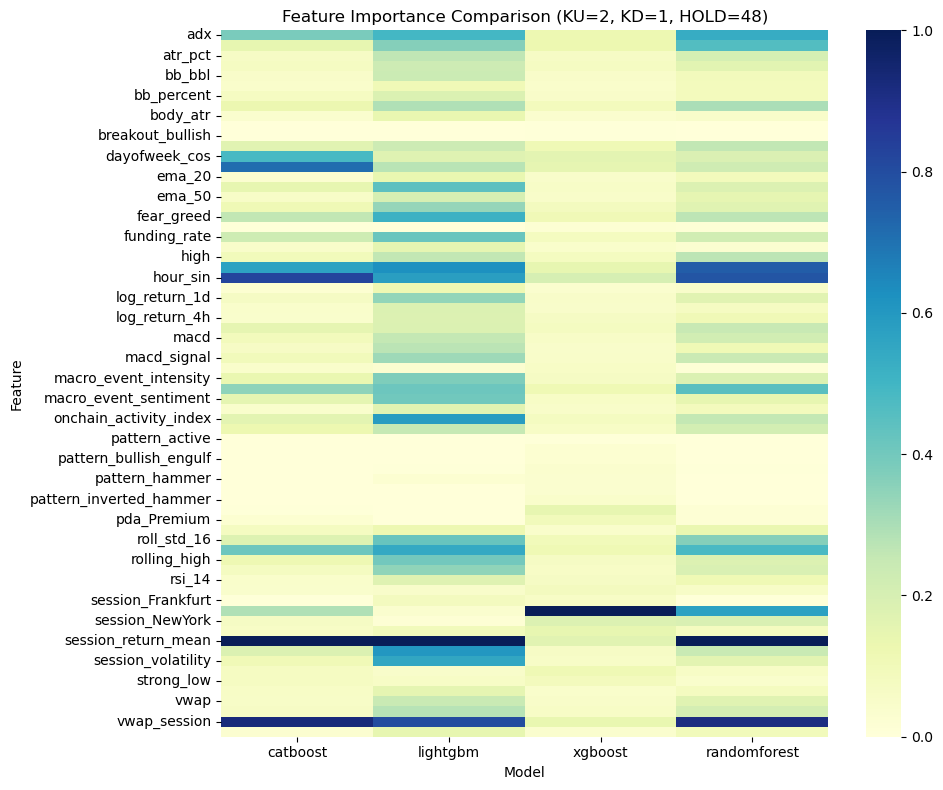

✅ Збережено: artifacts\feature_importance_comparison_ku2_kd1_hold48.csv


In [27]:

# ───────────────────────────────────────────────
# Параметри
KU, KD, HOLD = 2, 1, 48
artifacts_dir = Path("artifacts")

# ──────────────────────────────────────────────
df_labeled = triple_barrier_label(
    df,
    close="close",
    high="high",
    low="low",
    volatility="atr_14",
    ku=KU,
    kd=KD,
    hold=HOLD
)

train_df, val_df, test_df, scaler = split_scale(
    df_labeled,
    target_cols="y",
    test_size=0.15,
    val_size=0.15,
    scale=True
)

X_train = train_df.drop(columns=["y"])

# ───────────────────────────────────────────────
# Завантаження моделей
models = {
    "catboost": joblib.load(artifacts_dir / f"cat/catboost_optuna_ku{KU}_kd{KD}_hold{HOLD}.pkl"),
    "lightgbm": joblib.load(artifacts_dir / "lgbm" / f"best_lgbm_ku{KU}_kd{KD}_hold{HOLD}.pkl"),
    "xgboost": joblib.load(artifacts_dir / "xgb" / f"best_xgb_ku{KU}_kd{KD}_hold{HOLD}.pkl"),
    "randomforest": joblib.load(artifacts_dir / f"rf/best_rf_ku{KU}_kd{KD}_hold{HOLD}.pkl")
}

# ───────────────────────────────────────────────
# Отримання важливостей фічей із назвами
feature_importances = {}

for name, model in models.items():
    try:
        if hasattr(model, "feature_importances_"):
            imp = model.feature_importances_
        elif hasattr(model, "get_feature_importance"):  # для CatBoost
            imp = model.get_feature_importance()
        else:
            continue

        # DataFrame із назвами
        df_imp = pd.DataFrame({
            "Feature": X_train.columns,
            "Importance": imp
        })
        df_imp["Importance"] = df_imp["Importance"] / df_imp["Importance"].max()  # нормалізація 0–1
        feature_importances[name] = df_imp

    except Exception as e:
        print(f"⚠️ Не вдалося отримати важливості для {name}: {e}")

# ───────────────────────────────────────────────
# Об’єднання всіх важливостей
merged = None
for name, df_imp in feature_importances.items():
    df_imp = df_imp.rename(columns={"Importance": name})
    merged = df_imp if merged is None else merged.merge(df_imp, on="Feature", how="outer")

# Замінимо NaN на 0
merged = merged.fillna(0)
merged = merged.set_index("Feature")

# ───────────────────────────────────────────────
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(merged, cmap="YlGnBu", annot=False)
plt.title(f"Feature Importance Comparison (KU={KU}, KD={KD}, HOLD={HOLD})")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Збереження
output_path = artifacts_dir / f"feature_importance_comparison_ku{KU}_kd{KD}_hold{HOLD}.csv"
merged.to_csv(output_path)
print(f"✅ Збережено: {output_path}")


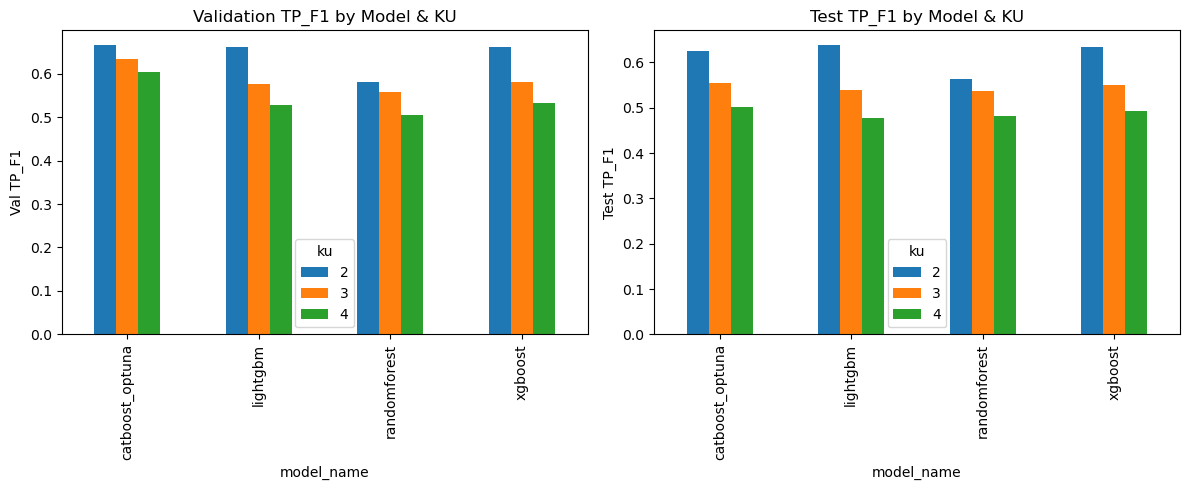

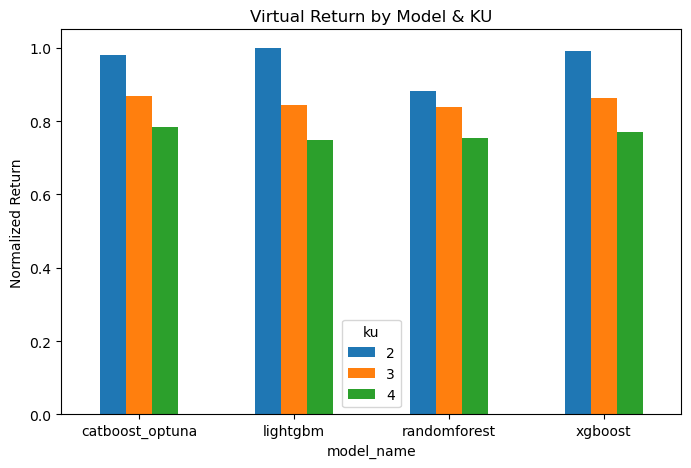

🏆 Найкраща модель:
model_name    lightgbm
ku                   2
kd                   1
hold                48
val_tp_f1     0.660623
test_tp_f1    0.638717
thr_tp        0.415759
thr_sl            0.33
Name: 1, dtype: object


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Завантаження CSV
df = pd.read_csv("artifacts/thresholds/dualthreshold_summary.csv")

# 2️⃣ Витягуємо test_tp_f1 з JSON-поля
df["test_tp_f1"] = df["test_metrics"].apply(
    lambda x: ast.literal_eval(x).get("tp_f1") if pd.notna(x) else None
)

# 3️⃣ Таблиці F1
pivot_f1_val = df.pivot(index="model_name", columns="ku", values="val_tp_f1")
pivot_f1_test = df.pivot(index="model_name", columns="ku", values="test_tp_f1")

# 4️⃣ Візуалізація F1 для кожного KU
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pivot_f1_val.plot(kind="bar", ax=axes[0], title="Validation TP_F1 by Model & KU", ylabel="Val TP_F1")
pivot_f1_test.plot(kind="bar", ax=axes[1], title="Test TP_F1 by Model & KU", ylabel="Test TP_F1")
plt.tight_layout()
plt.show()

# 5️⃣ "Віртуальна прибутковість" (на основі F1)
df["virtual_return"] = df["test_tp_f1"] / df["test_tp_f1"].max()
pivot_return = df.pivot(index="model_name", columns="ku", values="virtual_return")

pivot_return.plot(kind="bar", title="Virtual Return by Model & KU", ylabel="Normalized Return", figsize=(8,5))
plt.xticks(rotation=0)
plt.show()

# 6️⃣ Фінальна модель
best_row = df.loc[df["test_tp_f1"].idxmax()]
print("🏆 Найкраща модель:")
print(best_row[["model_name", "ku", "kd", "hold", "val_tp_f1", "test_tp_f1", "thr_tp", "thr_sl"]])

# 7️⃣ Збереження підсумкової таблиці
df.to_csv("artifacts/thresholds/final_model_summary.csv", index=False)



In [38]:
# параметри
KU, KD, HOLD = 2, 1, 48
thr_tp, thr_sl = 0.42, 0.33

# завантаження моделей
cat = joblib.load(f"artifacts/cat/catboost_optuna_ku{KU}_kd{KD}_hold{HOLD}.pkl")
lgb = joblib.load(f"artifacts/lgbm/best_lgbm_ku{KU}_kd{KD}_hold{HOLD}.pkl")
xgb = joblib.load(f"artifacts/xgb/best_xgb_ku{KU}_kd{KD}_hold{HOLD}.pkl")

# обчислення ймовірностей
probas = {
    "CatBoost": cat.predict_proba(X_test),
    "LightGBM": lgb.predict_proba(X_test),
    "XGBoost": xgb.predict_proba(X_test)
}

# комбінації моделей (по 2 і всі 3)
combos = [
    ("LightGBM", "XGBoost"),
    ("LightGBM", "CatBoost"),
    ("XGBoost", "CatBoost"),
    ("LightGBM", "XGBoost", "CatBoost")
]

results = []

for combo in combos:
    # рівні ваги
    n = len(combo)
    weights = [1/n] * n
    proba_ens = np.zeros_like(list(probas.values())[0])

    for w, name in zip(weights, combo):
        proba_ens += w * probas[name]

    # dual threshold класифікація
    preds = preds_from_proba_dualthr(proba_ens, thr_tp, thr_sl)
    cm = confusion_matrix(y_test, preds, labels=[0,1,2])
    metrics = triple_barrier_metrics(cm)

    results.append({
        "ensemble": "+".join(combo),
        **metrics
    })

# вивід
import pandas as pd
df_ens = pd.DataFrame(results)
df_ens = df_ens.round(4)

print(
    df_ens[
        ["ensemble", "tp_precision", "tp_recall", "tp_f1",
         "sl_precision", "sl_recall", "sl_f1", "macro_f1_tp_sl"]
    ]
)

df_ens.to_csv("artifacts/ensemble_combinations_results.csv", index=False)

                    ensemble  tp_precision  tp_recall   tp_f1  sl_precision  \
0           LightGBM+XGBoost        0.3579     0.7412  0.4827        0.8901   
1          LightGBM+CatBoost        0.3573     0.7754  0.4892        0.8990   
2           XGBoost+CatBoost        0.3578     0.7606  0.4867        0.8977   
3  LightGBM+XGBoost+CatBoost        0.3578     0.7601  0.4866        0.8933   

   sl_recall   sl_f1  macro_f1_tp_sl  
0     0.7333  0.8041          0.6434  
1     0.7039  0.7896          0.6394  
2     0.7063  0.7906          0.6386  
3     0.7183  0.7963          0.6414  


                    ensemble  tp_precision  tp_recall   tp_f1  sl_precision  \
0           LightGBM+XGBoost        0.3579     0.7412  0.4827        0.8901   
1          LightGBM+CatBoost        0.3573     0.7754  0.4892        0.8990   
2           XGBoost+CatBoost        0.3578     0.7606  0.4867        0.8977   
3  LightGBM+XGBoost+CatBoost        0.3578     0.7601  0.4866        0.8933   

   sl_recall   sl_f1  macro_precision_tp_sl  macro_recall_tp_sl  \
0     0.7333  0.8041                 0.6240              0.7373   
1     0.7039  0.7896                 0.6282              0.7396   
2     0.7063  0.7906                 0.6277              0.7335   
3     0.7183  0.7963                 0.6255              0.7392   

   macro_f1_tp_sl  
0          0.6434  
1          0.6394  
2          0.6386  
3          0.6414  


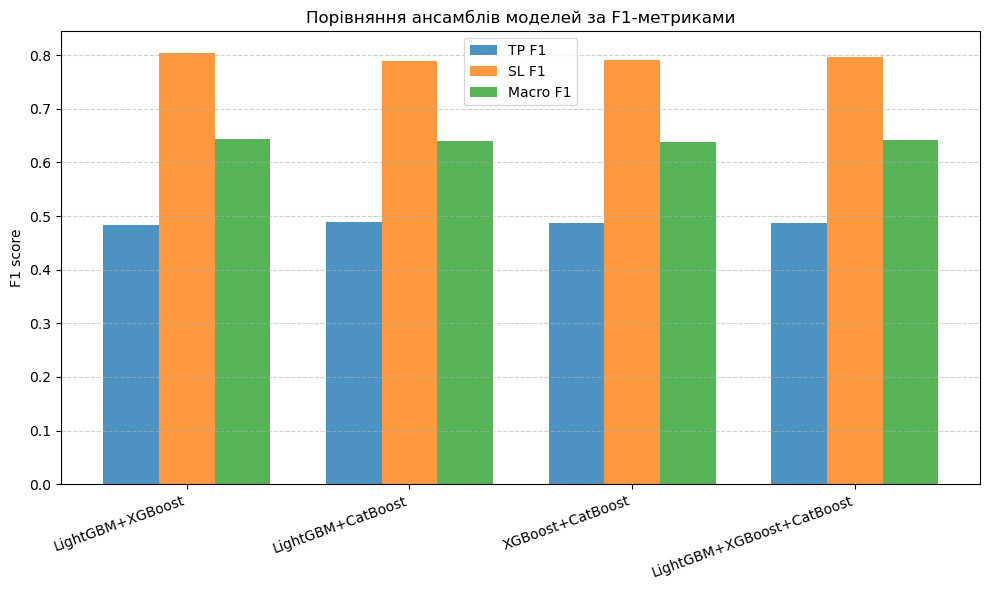

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Зчитуємо результати ансамблів
df_ens = pd.read_csv("artifacts/ensemble_combinations_results.csv")

# перевіряємо структуру
print(df_ens.head())

# 2️⃣ Стовпчиковий графік (Bar chart)
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.25
x = np.arange(len(df_ens))

ax.bar(x - bar_width, df_ens["tp_f1"], width=bar_width, label="TP F1", alpha=0.8)
ax.bar(x, df_ens["sl_f1"], width=bar_width, label="SL F1", alpha=0.8)
ax.bar(x + bar_width, df_ens["macro_f1_tp_sl"], width=bar_width, label="Macro F1", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(df_ens["ensemble"], rotation=20, ha="right")
ax.set_ylabel("F1 score")
ax.set_title("Порівняння ансамблів моделей за F1-метриками")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
